## Image Denoising via Quantum Reservoir Computing



In [2]:
import random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import os

SEED = 42  # Seed não especificada no paper

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

I0000 00:00:1780241176.948180   14236 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Dataset setup
"For the setup, we selected the first 1000 training images and 200 test images"

In [3]:
import numpy as np
from keras.datasets import mnist

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# test: first 200 MNIST test images
X_test = X_test_full[:200].astype(np.float32) / 255.0
y_test = y_test_full[:200]

# train/val: first 1000 MNIST train images, 80/20 split
X_1000 = X_train_full[:1000].astype(np.float32) / 255.0
y_1000 = y_train_full[:1000]

X_train, X_val, y_train, y_val = train_test_split(
    X_1000, y_1000, test_size=0.2, random_state=SEED, stratify=y_1000
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (800, 28, 28), Val: (200, 28, 28), Test: (200, 28, 28)


### Noise dataset
"Noisy datasets were synthesized by applying multiplicative speckle noise, modeled as $I˜ = I · (1 + σ · \mathcal{N}(0, 1))$, with $\sigma = 0.7$, cut to [0,1]"

Note: Cut, not normalized

In [4]:
def apply_noise(X: np.ndarray, sigma: float, seed: int) -> np.ndarray:
    """I˜ = clip(I · (1 + σ · N(0,1)), 0, 1). X must be float32 in [0,1]."""
    rng = np.random.default_rng(seed)
    eps = rng.normal(0, sigma, size=X.shape).astype(np.float32)
    return np.clip(X * (1 + eps), 0.0, 1.0)

In [5]:
SIGMA = 0.7
X_train_noisy = apply_noise(X_train, sigma=SIGMA, seed=SEED)
X_val_noisy   = apply_noise(X_val,   sigma=SIGMA, seed=SEED + 1)
X_test_noisy  = apply_noise(X_test,  sigma=SIGMA, seed=SEED + 2)

### Visualize Clean vs Noisy

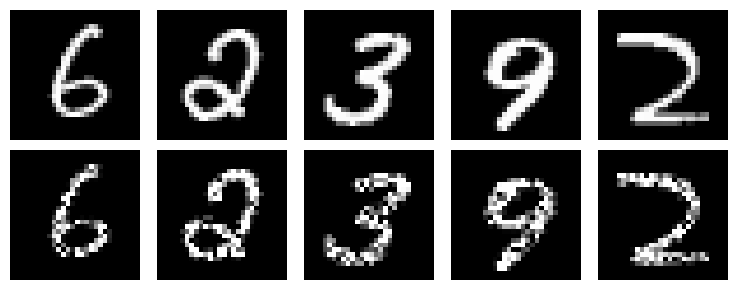

In [6]:
import matplotlib.pyplot as plt

n = 5
fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))

for col in range(n):
    axes[0, col].imshow(X_train[col], cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_train_noisy[col], cmap="gray", vmin=0, vmax=1)
    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("clean", fontsize=9)
axes[1, 0].set_ylabel("noisy", fontsize=9)
plt.tight_layout()
plt.show()

### PCA

"PCA identifies an optimal orthogonal basis ${u_1, ... , u_M }$ for the clean training data by finding the directions of maximal variance. The transformation projects the high-dimensional noisy vector $y_i$ onto the subspace spanned by the first $d ≪ M$ principal components"

In [7]:
from sklearn.decomposition import PCA

N_COMPONENTS = 18  # Máximo usado no paper

X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (800, 784)

pca = PCA(n_components=N_COMPONENTS)
pca.fit(X_train_flat)

explained = pca.explained_variance_ratio_
print(f"Explained variance per component: {np.round(explained, 4)}")
print(f"Cumulative explained variance ({N_COMPONENTS} PCs): {explained.sum():.4f}")

Explained variance per component: [0.1024 0.0762 0.0672 0.0537 0.049  0.0444 0.0353 0.0302 0.0292 0.0217
 0.0207 0.0187 0.0183 0.018  0.0165 0.0148 0.0135 0.0131]
Cumulative explained variance (18 PCs): 0.6430


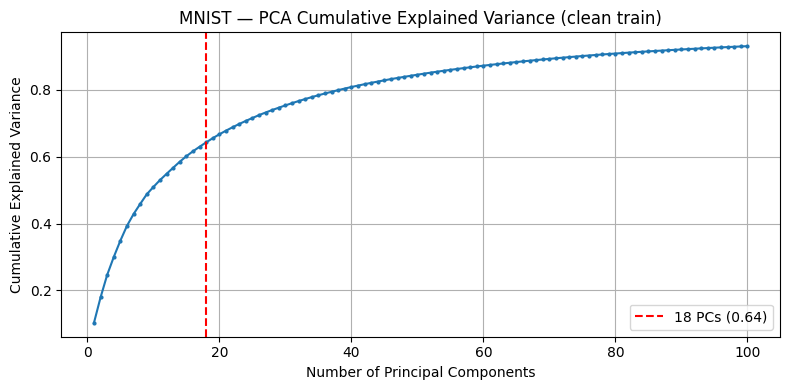

Explained variance ratio added at each PC (10 first): [0.10240015 0.07621094 0.06724212 0.05374014 0.0489572  0.0443931
 0.03529527 0.03018283 0.02915043 0.02173361]


In [8]:
pca_full = PCA(n_components=100)
pca_full.fit(X_train_flat)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 101), cumulative_var, marker=".", markersize=4)
plt.axvline(N_COMPONENTS, color="red", linestyle="--", label=f"{N_COMPONENTS} PCs ({cumulative_var[N_COMPONENTS-1]:.2f})")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("MNIST — PCA Cumulative Explained Variance (clean train)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Explained variance ratio added at each PC (10 first): {pca.explained_variance_ratio_[:10]}")

### PCA reconstruction

Here we ask a question: when we crop the image to the first principal components, how good are the loss metrics? This is the information that will be fed into the MPL denoiser. When making experiments with different datasets we will try to pick a number of principal components as to have close loss metrics.

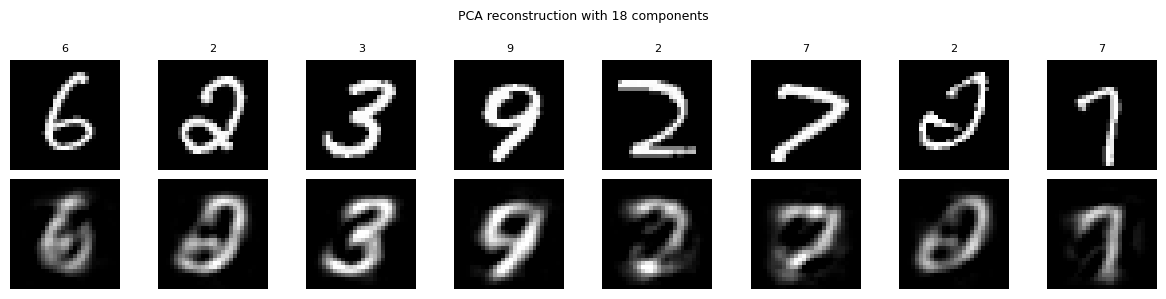

In [59]:
X_train_projected   = pca.transform(X_train_flat)          # (800, 18)
X_train_reconstructed = pca.inverse_transform(X_train_projected)  # (800, 784)

n = 8
fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))

for col in range(n):
    axes[0, col].imshow(X_train[col],                          cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_train_reconstructed[col].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(str(y_train[col]), fontsize=8)
    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("original", fontsize=8)
axes[1, 0].set_ylabel(f"{N_COMPONENTS} PCs", fontsize=8)
plt.suptitle(f"PCA reconstruction with {N_COMPONENTS} components", fontsize=9)
plt.tight_layout()
plt.show()

In [60]:
mse_pca = np.mean((X_train_flat - X_train_reconstructed) ** 2)
print(f"PCA reconstruction MSE ({N_COMPONENTS} components, train set): {mse_pca:.6f}")

PCA reconstruction MSE (18 components, train set): 0.023598


Projetar as versões ruidosas nos eixos do PCA

In [55]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

X_train_noisy_flat = X_train_noisy.reshape(X_train_noisy.shape[0], -1)
X_val_noisy_flat   = X_val_noisy.reshape(X_val_noisy.shape[0], -1)
X_test_noisy_flat  = X_test_noisy.reshape(X_test_noisy.shape[0], -1)

X_train_noisy_pca = pca.transform(X_train_noisy_flat)  # (800, 18)
X_val_noisy_pca   = pca.transform(X_val_noisy_flat)    # (100, 18)
X_test_noisy_pca  = pca.transform(X_test_noisy_flat)   # (100, 18)

print(f"Train: {X_train_noisy_pca.shape}, Val: {X_val_noisy_pca.shape}, Test: {X_test_noisy_pca.shape}")

Train: (800, 18), Val: (200, 18), Test: (200, 18)


### Model definition

In [56]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout

tf.random.set_seed(SEED)

model = Sequential([
    Dense(1024, activation="relu", input_shape=(N_COMPONENTS,)),
    Dropout(0.3),
    Dense(512, activation="relu"),
    Dropout(0.3),
    Dense(28 * 28, activation="sigmoid"),
])

model.summary()

/home/jvpcms/ime/PFC/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 1024)           │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 946,448 (3.61 MB)

 Trainable params: 946,448 (3.61 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
)

early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = model.fit(
    X_train_noisy_pca, X_train_flat,
    validation_data=(X_val_noisy_pca, X_val_flat),
    epochs=500,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/500


I0000 00:00:1780172009.165435  127228 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18458__.8


 1/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - loss: 0.2318

I0000 00:00:1780172010.764980  127229 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18458__.8


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 257ms/step - loss: 0.1400 - val_loss: 0.0666
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0675 - val_loss: 0.0559
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0579 - val_loss: 0.0456
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0481 - val_loss: 0.0395
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0418 - val_loss: 0.0350
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0372 - val_loss: 0.0319
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0341 - val_loss: 0.0293
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0315 - val_loss: 0.0274
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0297 - val_loss: 0.0259
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0282 - val_loss: 0.0248
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0269 - val_loss: 0.0238
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0259 - val_

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


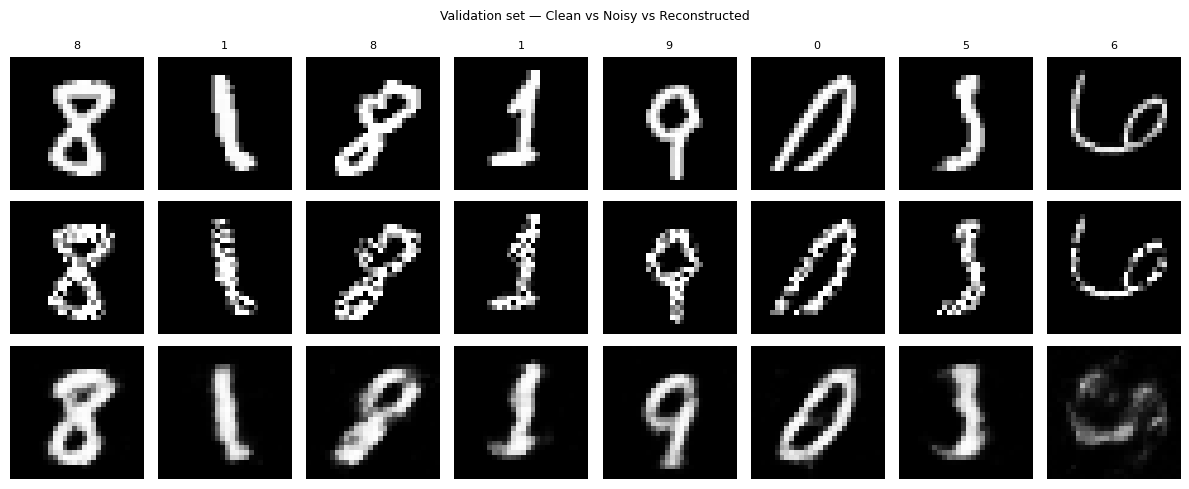

In [58]:
X_val_reconstructed = model.predict(X_val_noisy_pca).reshape(-1, 28, 28)

n = 8
fig, axes = plt.subplots(3, n, figsize=(n * 1.5, 5))
row_labels = ["clean", "noisy", "reconstructed"]

for col in range(n):
    axes[0, col].imshow(X_val[col],             cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_val_noisy[col],       cmap="gray", vmin=0, vmax=1)
    axes[2, col].imshow(X_val_reconstructed[col], cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(str(y_val[col]), fontsize=8)
    for row in range(3):
        axes[row, col].axis("off")

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=8)

plt.suptitle("Validation set — Clean vs Noisy vs Reconstructed", fontsize=9)
plt.tight_layout()
plt.show()